# CS3807 – Deep Learning Laboratory — Experiment 5
## Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

**Runtime target:** Google Colab, **CPU only**, total run time **well under 3 hours**.

**Design note (read this first):**
To make 15 plots + 4 studies + CV + fine-tuning feasible on CPU in a short time, we use the standard
transfer-learning trick of **precomputing MobileNetV2 bottleneck features once** (a single frozen forward
pass over a modest, fixed subsample of the Oxford-IIIT Pet dataset). Every subsequent study (initialization,
regularization, optimizers, hyperparameters, cross-validation) then trains only a small dense **classifier
head** on these cached 1280-D feature vectors — this takes seconds per run instead of minutes, while still
faithfully demonstrating each concept. Only the **fine-tuning** task (Task 7B) and the **final model**
(Task 9) touch the actual MobileNetV2 convolutional layers with backpropagation, and those are limited to
a small subset and few epochs to stay within the time budget.

All plots are saved as **.eps at 600 dpi** into `/content/plots/`, then zipped for download at the end.

Run the cells **in order, top to bottom**.


## Task 0 — Setup & Configuration

In [1]:
# Task 0.1 — Imports
# NOTE: we deliberately do NOT use tensorflow_datasets here. On current Colab images it
# pulls in a newer tensorflow_metadata build that requires a newer protobuf than the one
# already installed, causing "module 'tensorflow_datasets' has no attribute 'load'".
# Instead we download the official Oxford-IIIT Pet archive directly and load it with PIL.

import os, io, time, json, random, zipfile, tarfile, urllib.request
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

tf.config.set_visible_devices([], 'GPU')   # force CPU, matches "colab CPU only" requirement
print("TF version:", tf.__version__)
print("Visible devices:", tf.config.get_visible_devices())


TF version: 2.20.0
Visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
# Task 0.2 — Global config (reduced epochs / CV folds to fit the time budget)
IMG_SIZE      = 224
NUM_CLASSES   = 37                 # Oxford-IIIT Pet breeds

N_TRAIN       = 900                # reduced subsample sizes (full dataset ~7349 images)
N_VAL         = 300
N_TEST        = 300

EPOCHS_SMALL  = 8                  # used for init / reg / optimizer / hyperparam studies
EPOCHS_FT     = 3                  # fine-tuning epochs (real backprop through MobileNetV2)
CV_FOLDS      = 3                  # reduced from 5 -> 3 to save time
CV_EPOCHS     = 6

PLOT_DIR = "/content/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(fig, name):
    path = f"{PLOT_DIR}/{name}.eps"
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


## Task 1 — Load Dataset & Precompute MobileNetV2 Bottleneck Features

In [3]:
# Task 1.1 — Download the official Oxford-IIIT Pet archive (images + breed annotations)
DATA_DIR = "/content/oxford_pet"
os.makedirs(DATA_DIR, exist_ok=True)

IMAGES_URL      = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
ANNOTATIONS_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

def download_and_extract(url, dest_dir):
    fname = os.path.join(dest_dir, url.split('/')[-1])
    if not os.path.exists(fname):
        print("Downloading", url, "...")
        urllib.request.urlretrieve(url, fname)
    print("Extracting", fname, "...")
    with tarfile.open(fname) as tf_ar:
        tf_ar.extractall(dest_dir)

download_and_extract(IMAGES_URL, DATA_DIR)
download_and_extract(ANNOTATIONS_URL, DATA_DIR)

IMAGE_DIR = os.path.join(DATA_DIR, "images")
LIST_TXT  = os.path.join(DATA_DIR, "annotations", "list.txt")
print("Images dir:", IMAGE_DIR)
print("Annotations file:", LIST_TXT)


Extracting /content/oxford_pet/images.tar.gz ...


/tmp/ipykernel_3267/332745432.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf_ar.extractall(dest_dir)


Extracting /content/oxford_pet/annotations.tar.gz ...
Images dir: /content/oxford_pet/images
Annotations file: /content/oxford_pet/annotations/list.txt


In [ ]:
# Task 1.2 — Parse breed labels (list.txt: <filename> <class-id 1-37> <species> <breed-id>)
entries = []
CLASS_NAMES = {}   # class_id (0-indexed) -> human-readable breed name, used later for
                    # confusion-matrix / misclassified-image labels instead of raw indices
with open(LIST_TXT) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split()
        fname, class_id = parts[0], int(parts[1])
        img_path = os.path.join(IMAGE_DIR, fname + ".jpg")
        if os.path.exists(img_path):
            entries.append((img_path, class_id - 1))   # 0-indexed, 37 breeds
            if (class_id - 1) not in CLASS_NAMES:
                # breed name = filename with the trailing "_<index>" stripped, e.g.
                # "Abyssinian_12" -> "Abyssinian", "British_Shorthair_5" -> "British Shorthair"
                breed = "_".join(fname.split("_")[:-1])
                CLASS_NAMES[class_id - 1] = breed.replace("_", " ")

print("Total labelled images found:", len(entries))
assert len(entries) >= (N_TRAIN + N_VAL + N_TEST), "Not enough images downloaded — check the archive extraction."
print("Number of breed classes discovered:", len(CLASS_NAMES))

rng = random.Random(SEED)
rng.shuffle(entries)

train_entries = entries[:N_TRAIN]
val_entries   = entries[N_TRAIN:N_TRAIN + N_VAL]
test_entries  = entries[N_TRAIN + N_VAL: N_TRAIN + N_VAL + N_TEST]
print(f"Train: {len(train_entries)}  Val: {len(val_entries)}  Test: {len(test_entries)}  (subsampled for CPU speed)")


In [5]:
# Task 1.3 — Load images with PIL (robust to the dataset's occasional CMYK/odd-mode JPEGs)
def load_images(entries, size=IMG_SIZE):
    imgs, labels = [], []
    for path, label in entries:
        try:
            img = Image.open(path).convert('RGB').resize((size, size))
            imgs.append(np.asarray(img, dtype=np.float32))
            labels.append(label)
        except Exception as e:
            print("Skipping unreadable image:", path, "-", e)
    return np.stack(imgs), np.array(labels)

t0 = time.time()
train_images, train_labels = load_images(train_entries)
val_images,   val_labels   = load_images(val_entries)
test_images,  test_labels  = load_images(test_entries)
print(f"Loaded images in {time.time()-t0:.1f}s")
print("Shapes:", train_images.shape, val_images.shape, test_images.shape)


Loaded images in 12.9s
Shapes: (900, 224, 224, 3) (300, 224, 224, 3) (300, 224, 224, 3)


In [6]:
# Task 1.4 — Build frozen MobileNetV2 base (ImageNet weights) and extract bottleneck features
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'          # -> 1280-D feature vector per image
)
base_model.trainable = False

def extract_features(images, labels, batch_size=32):
    feats = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size].copy()
        pre = tf.keras.applications.mobilenet_v2.preprocess_input(batch)
        f = base_model(pre, training=False).numpy()
        feats.append(f)
    return np.concatenate(feats), labels

t0 = time.time()
X_train, y_train = extract_features(train_images, train_labels)
X_val,   y_val   = extract_features(val_images,   val_labels)
X_test,  y_test  = extract_features(test_images,  test_labels)
print(f"Feature extraction done in {time.time()-t0:.1f}s")
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extraction done in 117.1s
Shapes: (900, 1280) (300, 1280) (300, 1280)


## Helper functions used by every study below
A small dense **classifier head** on top of the cached 1280-D features. Varying its
initializer / regularization / optimizer / hyperparameters reproduces every comparison
asked for in the lab, at a tiny fraction of the compute cost.

In [7]:
INIT_MAP = {
    'zero':   'zeros',
    'random': tf.keras.initializers.RandomNormal(stddev=0.05, seed=SEED),
    'xavier': 'glorot_uniform',
    'he':     'he_normal',
}

def build_head(init='he', dropout=0.0, use_bn=False, l2_reg=0.0):
    reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    kernel_init = INIT_MAP[init]
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(1280,)))
    model.add(tf.keras.layers.Dense(128, kernel_initializer=kernel_init, kernel_regularizer=reg))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=kernel_init))
    return model

def get_optimizer(name, lr=0.001):
    name = name.lower()
    if name == 'sgd':       return tf.keras.optimizers.SGD(learning_rate=lr)
    if name == 'momentum':  return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    if name == 'rmsprop':   return tf.keras.optimizers.RMSprop(learning_rate=lr)
    if name == 'adam':      return tf.keras.optimizers.Adam(learning_rate=lr)
    raise ValueError(name)

def train_head(model, optimizer='adam', lr=0.001, epochs=EPOCHS_SMALL, batch_size=32,
                Xtr=None, ytr=None, Xva=None, yva=None, verbose=0):
    Xtr = X_train if Xtr is None else Xtr
    ytr = y_train if ytr is None else ytr
    Xva = X_val   if Xva is None else Xva
    yva = y_val   if yva is None else yva
    model.compile(optimizer=get_optimizer(optimizer, lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    hist = model.fit(Xtr, ytr, validation_data=(Xva, yva),
                      epochs=epochs, batch_size=batch_size, verbose=verbose)
    elapsed = time.time() - t0
    return hist, elapsed


## Task 2 — Weight Initialization Study

In [ ]:
inits = ['zero', 'random', 'xavier', 'he']
init_histories, init_times = {}, {}
for init in inits:
    tf.random.set_seed(SEED)
    m = build_head(init=init)
    hist, secs = train_head(m, optimizer='adam', lr=0.001)
    init_histories[init] = hist.history
    init_times[init] = secs
    print(f"init={init:8s}  final val_acc={hist.history['val_accuracy'][-1]:.3f}  ({secs:.1f}s)")


In [ ]:
# Plot 1 — Training Loss vs Epoch (SEPARATE graph for each initialization method, per manual)
for init in inits:
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(init_histories[init]['loss'], marker='o', color='tab:blue')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
    ax.set_title(f'Plot 1: Training Loss vs Epoch — {init.capitalize()} Initialization')
    save_plot(fig, f'Plot1_TrainLoss_Init_{init}')


In [ ]:
# Plot 2 — Validation Accuracy vs Epoch (SEPARATE graph for each initialization method, per manual)
for init in inits:
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(np.array(init_histories[init]['val_accuracy'])*100, marker='o', color='tab:orange')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
    ax.set_title(f'Plot 2: Validation Accuracy vs Epoch — {init.capitalize()} Initialization')
    save_plot(fig, f'Plot2_ValAcc_Init_{init}')


**Inference (fill in after running):** Compare which initializer converges fastest / most stably.
Zero initialization typically stalls (symmetry problem — all neurons in a layer learn identically since
gradients are identical). He initialization usually converges fastest here because it is matched to ReLU
activations.

## Task 3 — Regularization and Overfitting Study

In [ ]:
reg_configs = {
    'None':       dict(init='he'),
    'L2':         dict(init='he', l2_reg=0.001),
    'Dropout':    dict(init='he', dropout=0.5),
    'BatchNorm':  dict(init='he', use_bn=True),
}
reg_histories, reg_times = {}, {}
for name, kwargs in reg_configs.items():
    tf.random.set_seed(SEED)
    m = build_head(**kwargs)
    hist, secs = train_head(m, optimizer='adam', lr=0.001, epochs=10)
    reg_histories[name] = hist.history
    reg_times[name] = secs
    print(f"{name:10s} final train_acc={hist.history['accuracy'][-1]:.3f} "
          f"val_acc={hist.history['val_accuracy'][-1]:.3f}  ({secs:.1f}s)")


Saved: /content/plots/Plot3_TrainValAcc_Reg.eps


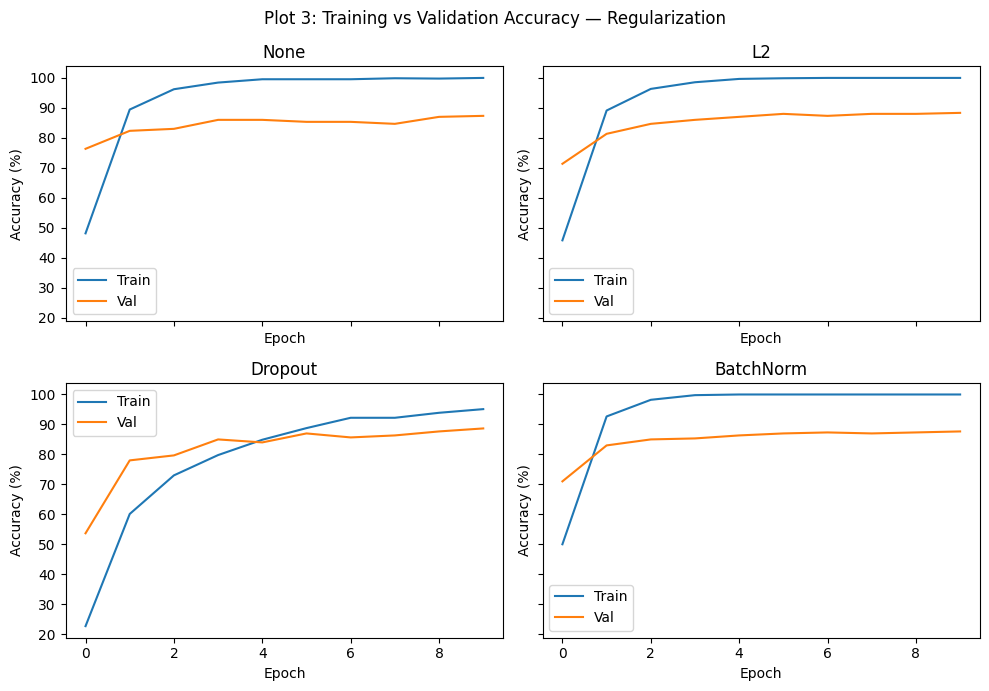

In [12]:
# Plot 3 — Training & Validation Accuracy vs Epoch (one subplot per config)
fig, axes = plt.subplots(2, 2, figsize=(10,7), sharex=True, sharey=True)
for ax, (name, h) in zip(axes.ravel(), reg_histories.items()):
    ax.plot(np.array(h['accuracy'])*100, label='Train')
    ax.plot(np.array(h['val_accuracy'])*100, label='Val')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.legend()
fig.suptitle('Plot 3: Training vs Validation Accuracy — Regularization')
fig.tight_layout()
save_plot(fig, 'Plot3_TrainValAcc_Reg')


Saved: /content/plots/Plot4_TrainValLoss_Reg.eps


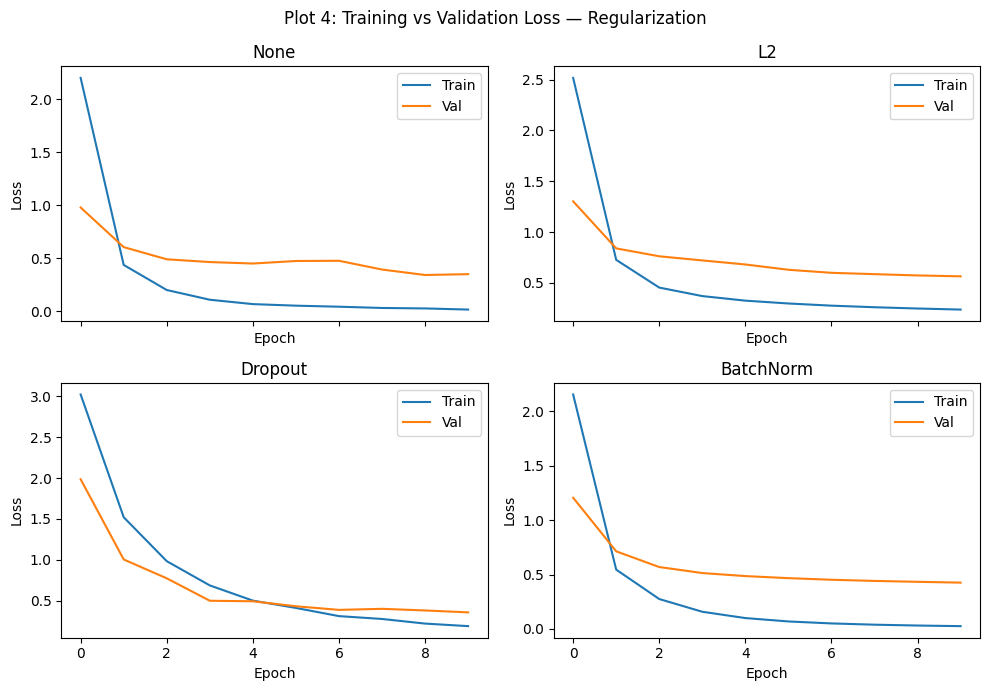

In [13]:
# Plot 4 — Training & Validation Loss vs Epoch (one subplot per config)
fig, axes = plt.subplots(2, 2, figsize=(10,7), sharex=True)
for ax, (name, h) in zip(axes.ravel(), reg_histories.items()):
    ax.plot(h['loss'], label='Train')
    ax.plot(h['val_loss'], label='Val')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
fig.suptitle('Plot 4: Training vs Validation Loss — Regularization')
fig.tight_layout()
save_plot(fig, 'Plot4_TrainValLoss_Reg')


**Inference (fill in after running):** The 'None' configuration typically shows the largest
generalization gap (train accuracy rising while validation accuracy plateaus / validation loss rises).
Dropout, L2 and BatchNorm each reduce this gap to varying degrees.

## Task 4 — Batch Normalization: Numerical Example + Effect Study

In [14]:
# Task 4.1 — Numerical example exactly as in the lab sheet
x = np.array([2.0, 4.0, 6.0, 8.0])
mu = x.mean()
var = ((x - mu) ** 2).mean()
eps = 1e-8
x_hat = (x - mu) / np.sqrt(var + eps)
gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"mu_B  = {mu}")
print(f"var_B = {var}")
print(f"sqrt(var_B) = {np.sqrt(var):.3f}")
print("x_hat =", np.round(x_hat, 3))
print("y (gamma=1, beta=0) =", np.round(y, 3))


mu_B  = 5.0
var_B = 5.0
sqrt(var_B) = 2.236
x_hat = [-1.342 -0.447  0.447  1.342]
y (gamma=1, beta=0) = [-1.342 -0.447  0.447  1.342]


In [15]:
# Task 4.2 — With vs Without BatchNorm (classifier head), same protocol as Task 3
tf.random.set_seed(SEED)
m_no_bn = build_head(init='he', use_bn=False)
hist_no_bn, _ = train_head(m_no_bn, optimizer='adam', lr=0.001, epochs=10)

tf.random.set_seed(SEED)
m_bn = build_head(init='he', use_bn=True)
hist_bn, _ = train_head(m_bn, optimizer='adam', lr=0.001, epochs=10)


Saved: /content/plots/Plot5_BN_Comparison.eps


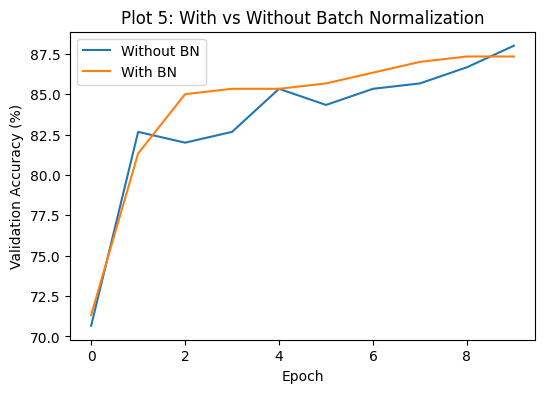

In [16]:
# Plot 5 — With vs Without Batch Normalization
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(np.array(hist_no_bn.history['val_accuracy'])*100, label='Without BN')
ax.plot(np.array(hist_bn.history['val_accuracy'])*100, label='With BN')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 5: With vs Without Batch Normalization')
ax.legend()
save_plot(fig, 'Plot5_BN_Comparison')


## Task 5 — Optimizer Comparison (SGD, Momentum, RMSProp, Adam)

In [17]:
optimizers = ['sgd', 'momentum', 'rmsprop', 'adam']
opt_histories, opt_times = {}, {}
for opt in optimizers:
    tf.random.set_seed(SEED)
    m = build_head(init='he')
    hist, secs = train_head(m, optimizer=opt, lr=0.001, epochs=10)
    opt_histories[opt] = hist.history
    opt_times[opt] = secs
    print(f"{opt:9s} final_loss={hist.history['loss'][-1]:.3f}  "
          f"best_val_acc={max(hist.history['val_accuracy']):.3f}  ({secs:.1f}s)")


sgd       final_loss=3.102  best_val_acc=0.200  (2.7s)
momentum  final_loss=0.561  best_val_acc=0.797  (2.9s)
rmsprop   final_loss=0.002  best_val_acc=0.863  (4.7s)
adam      final_loss=0.013  best_val_acc=0.890  (3.5s)


Saved: /content/plots/Plot6_TrainLoss_Optimizers.eps


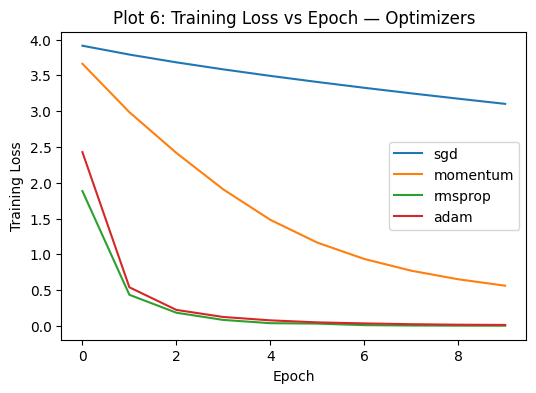

In [18]:
# Plot 6 — Training Loss vs Epoch (optimizers)
fig, ax = plt.subplots(figsize=(6,4))
for opt in optimizers:
    ax.plot(opt_histories[opt]['loss'], label=opt)
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Plot 6: Training Loss vs Epoch — Optimizers')
ax.legend()
save_plot(fig, 'Plot6_TrainLoss_Optimizers')


Saved: /content/plots/Plot7_ValAcc_Optimizers.eps


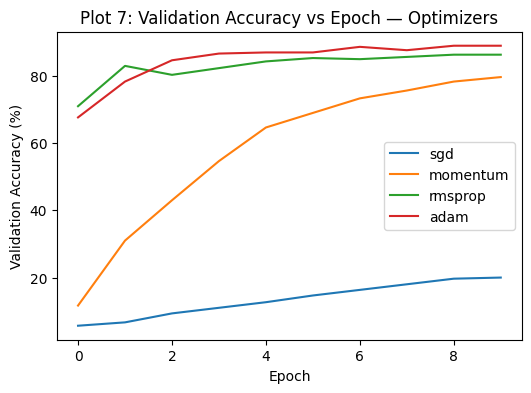

In [19]:
# Plot 7 — Validation Accuracy vs Epoch (optimizers)
fig, ax = plt.subplots(figsize=(6,4))
for opt in optimizers:
    ax.plot(np.array(opt_histories[opt]['val_accuracy'])*100, label=opt)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 7: Validation Accuracy vs Epoch — Optimizers')
ax.legend()
save_plot(fig, 'Plot7_ValAcc_Optimizers')


In [ ]:
# Optimizer summary table (Final Loss, Best Val Acc, Epoch to Converge, Time) — Section 8 table
import pandas as pd

opt_rows = []
for opt in optimizers:
    h = opt_histories[opt]
    best = max(h['val_accuracy'])
    conv_epoch = next(i for i, v in enumerate(h['val_accuracy']) if v >= best - 0.01) + 1
    opt_rows.append({
        'Optimizer': opt,
        'Final Loss': round(h['loss'][-1], 3),
        'Best Val. Accuracy (%)': round(best * 100, 2),
        'Epoch to Converge': conv_epoch,
        'Time (s)': round(opt_times[opt], 1),
    })
optimizer_table = pd.DataFrame(opt_rows).set_index('Optimizer')
optimizer_table


## Task 6 — CNN / Training Hyperparameter Tuning

In [ ]:
# Task 6.1 — Learning Rate sweep (baseline: adam, batch=32, dropout=0.25)
lrs = [0.001, 0.0001]
lr_results, lr_times = {}, {}
for lr in lrs:
    tf.random.set_seed(SEED)
    m = build_head(init='he', dropout=0.25)
    hist, secs = train_head(m, optimizer='adam', lr=lr, epochs=8, batch_size=32)
    lr_results[lr] = hist.history['val_accuracy'][-1] * 100
    lr_times[lr] = secs
    print(f"lr={lr:<8} final val_acc={lr_results[lr]:.2f}%  ({secs:.1f}s)")


Saved: /content/plots/Plot8_LR_vs_ValAcc.eps


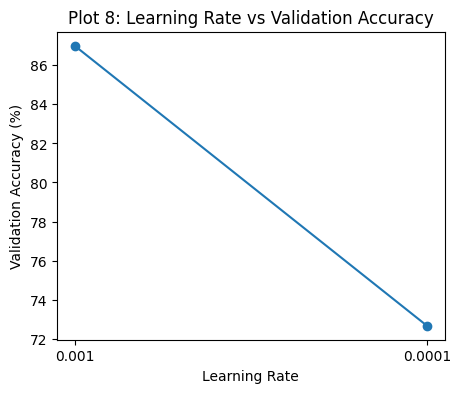

In [22]:
# Plot 8 — Learning Rate vs Validation Accuracy
fig, ax = plt.subplots(figsize=(5,4))
ax.plot([str(lr) for lr in lrs], [lr_results[lr] for lr in lrs], marker='o')
ax.set_xlabel('Learning Rate'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 8: Learning Rate vs Validation Accuracy')
save_plot(fig, 'Plot8_LR_vs_ValAcc')


In [ ]:
# Task 6.2 — Batch Size sweep
batch_sizes = [16, 32, 64]
bs_results, bs_times = {}, {}
for bs in batch_sizes:
    tf.random.set_seed(SEED)
    m = build_head(init='he', dropout=0.25)
    hist, secs = train_head(m, optimizer='adam', lr=0.001, epochs=8, batch_size=bs)
    bs_results[bs] = hist.history['val_accuracy'][-1] * 100
    bs_times[bs] = secs
    print(f"batch_size={bs:<4} final val_acc={bs_results[bs]:.2f}%  ({secs:.1f}s)")


Saved: /content/plots/Plot9_BatchSize_vs_ValAcc.eps


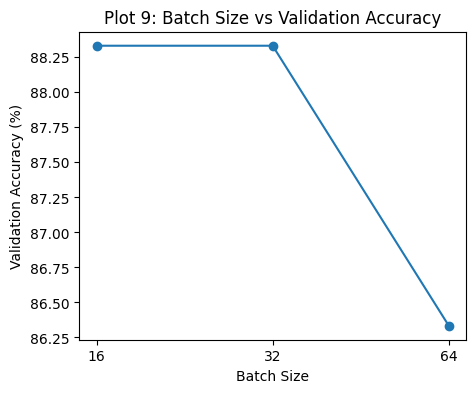

In [24]:
# Plot 9 — Batch Size vs Validation Accuracy
fig, ax = plt.subplots(figsize=(5,4))
ax.plot([str(b) for b in batch_sizes], [bs_results[b] for b in batch_sizes], marker='o')
ax.set_xlabel('Batch Size'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 9: Batch Size vs Validation Accuracy')
save_plot(fig, 'Plot9_BatchSize_vs_ValAcc')


In [ ]:
# Task 6.3 — Dropout Rate sweep
dropout_rates = [0.0, 0.25, 0.5]
do_results, do_times = {}, {}
for dr in dropout_rates:
    tf.random.set_seed(SEED)
    m = build_head(init='he', dropout=dr)
    hist, secs = train_head(m, optimizer='adam', lr=0.001, epochs=8, batch_size=32)
    do_results[dr] = hist.history['val_accuracy'][-1] * 100
    do_times[dr] = secs
    print(f"dropout={dr:<5} final val_acc={do_results[dr]:.2f}%  ({secs:.1f}s)")


Saved: /content/plots/Plot10_Dropout_vs_ValAcc.eps


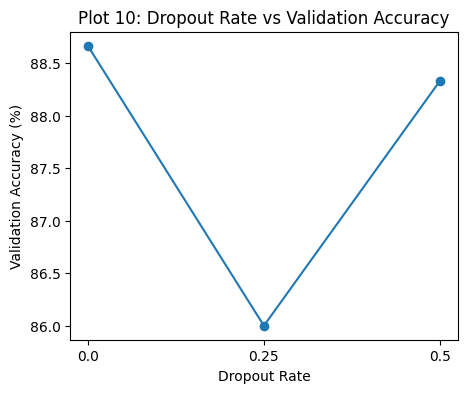

In [26]:
# Plot 10 — Dropout Rate vs Validation Accuracy
fig, ax = plt.subplots(figsize=(5,4))
ax.plot([str(d) for d in dropout_rates], [do_results[d] for d in dropout_rates], marker='o')
ax.set_xlabel('Dropout Rate'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 10: Dropout Rate vs Validation Accuracy')
save_plot(fig, 'Plot10_Dropout_vs_ValAcc')


### CNN Hyperparameter Concepts (Section 9 of the manual)

- **Kernel / filter** — the small weight matrix (e.g. 3×3) slid across the input to detect local patterns.
- **Stride (S)** — the step size the kernel moves at each position; larger stride → smaller output, fewer computations.
- **Padding (P)** — zeros added around the input border so the kernel can also be centred on edge pixels ("same" vs "valid" padding).
- **Pooling** — a downsampling operation (max/average) that reduces spatial size and adds translation invariance.
- **Number of channels** — the depth of the feature maps (e.g. 3 for an RGB input, more after each conv layer).
- **Depthwise separable convolution** — splits a standard convolution into a *depthwise* convolution (one filter per input channel) followed by a *pointwise* 1×1 convolution that mixes channels; this is the core trick that makes MobileNetV2 far cheaper than a standard CNN of similar depth.

For a convolution with input size **N**, kernel size **K**, padding **P** and stride **S**, the output spatial dimension is

$$O = \left\lfloor \frac{N + 2P - K}{S} \right\rfloor + 1$$


In [ ]:
# Worked numeric example of the output-dimension formula O = floor((N + 2P - K) / S) + 1
def conv_output_dim(N, K, P, S):
    return (N + 2*P - K) // S + 1

# Example: a 224x224 input, 3x3 kernel, padding=1 ("same"-style), stride=2
N, K, P, S = 224, 3, 1, 2
O = conv_output_dim(N, K, P, S)
print(f"Input N={N}, Kernel K={K}, Padding P={P}, Stride S={S}  ->  Output O={O}x{O}")

# A second example: 3x3 kernel, no padding, stride=1 (typical 'valid' convolution)
N2, K2, P2, S2 = 224, 3, 0, 1
O2 = conv_output_dim(N2, K2, P2, S2)
print(f"Input N={N2}, Kernel K={K2}, Padding P={P2}, Stride S={S2}  ->  Output O={O2}x{O2}")


## Task 7 — Transfer Learning (Feature Extraction) vs Fine-Tuning
Case A reuses the cached bottleneck features (frozen base). Case B is the only place in this
notebook that unfreezes part of MobileNetV2 and backpropagates through it — kept to a small
subset and few epochs to stay within the CPU time budget.

In [27]:
# Case A — Feature Extraction (frozen base, train head only)
tf.random.set_seed(SEED)
head_fe = build_head(init='he', dropout=0.25)
hist_fe, secs_fe = train_head(head_fe, optimizer='adam', lr=0.001, epochs=8)
print(f"Feature extraction done in {secs_fe:.1f}s, final val_acc={hist_fe.history['val_accuracy'][-1]:.3f}")


Feature extraction done in 4.5s, final val_acc=0.867


In [28]:
# Case B — Fine-Tuning: unfreeze last 20 layers of MobileNetV2, train end-to-end
# Use a smaller image subset (real backprop through conv layers is the expensive part)
FT_TRAIN_N, FT_VAL_N = 400, 150
ft_train_ds = tf.data.Dataset.from_tensor_slices((train_images[:FT_TRAIN_N], train_labels[:FT_TRAIN_N])) \
                  .shuffle(200, seed=SEED).batch(16)
ft_val_ds   = tf.data.Dataset.from_tensor_slices((val_images[:FT_VAL_N], val_labels[:FT_VAL_N])).batch(16)

base_ft = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet', pooling='avg')
base_ft.trainable = True
for layer in base_ft.layers[:-20]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input)(inputs)
x = base_ft(x, training=True)
x = tf.keras.layers.Dense(128, kernel_initializer='he_normal', activation='relu')(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
ft_model = tf.keras.Model(inputs, outputs)

ft_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
hist_ft = ft_model.fit(ft_train_ds, validation_data=ft_val_ds, epochs=EPOCHS_FT, verbose=1)
secs_ft = time.time() - t0
print(f"Fine-tuning done in {secs_ft:.1f}s")


Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.0350 - loss: 3.9712 - val_accuracy: 0.0333 - val_loss: 3.7463
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.0650 - loss: 3.7794 - val_accuracy: 0.0400 - val_loss: 3.6454
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.0875 - loss: 3.5771 - val_accuracy: 0.0667 - val_loss: 3.5478
Fine-tuning done in 94.5s


Saved: /content/plots/Plot11_FeatExtract_vs_FineTune.eps


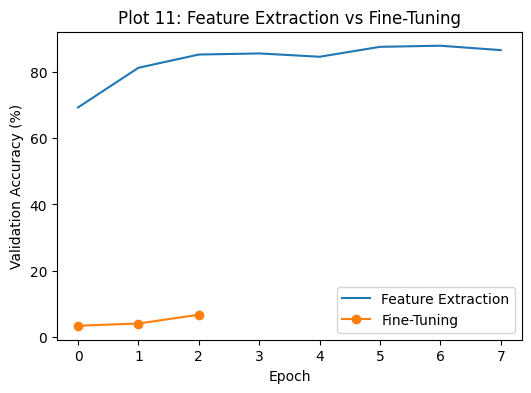

In [29]:
# Plot 11 — Feature Extraction vs Fine-Tuning (Validation Accuracy)
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(np.array(hist_fe.history['val_accuracy'])*100, label='Feature Extraction')
ax.plot(np.array(hist_ft.history['val_accuracy'])*100, label='Fine-Tuning', marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 11: Feature Extraction vs Fine-Tuning')
ax.legend()
save_plot(fig, 'Plot11_FeatExtract_vs_FineTune')


Saved: /content/plots/Plot12_Loss_FeatExtract_vs_FineTune.eps


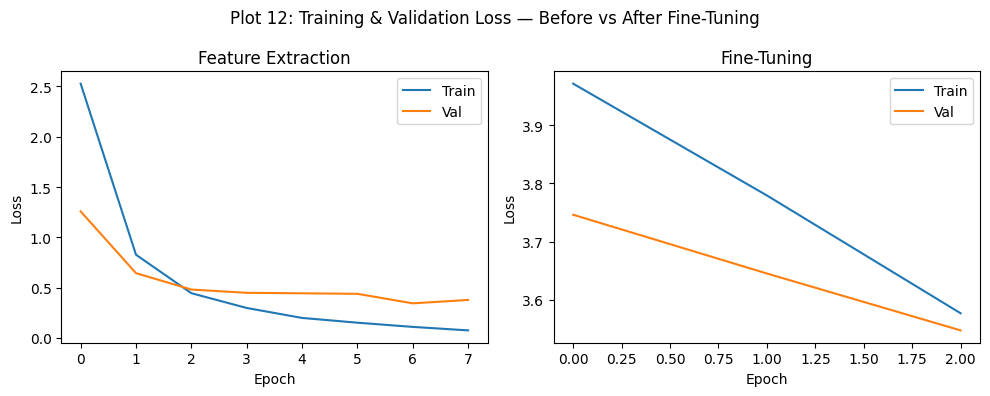

In [30]:
# Plot 12 — Training & Validation Loss: Feature Extraction vs Fine-Tuning
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(hist_fe.history['loss'], label='Train')
axes[0].plot(hist_fe.history['val_loss'], label='Val')
axes[0].set_title('Feature Extraction'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(hist_ft.history['loss'], label='Train')
axes[1].plot(hist_ft.history['val_loss'], label='Val')
axes[1].set_title('Fine-Tuning'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
fig.suptitle('Plot 12: Training & Validation Loss — Before vs After Fine-Tuning')
fig.tight_layout()
save_plot(fig, 'Plot12_Loss_FeatExtract_vs_FineTune')


**Discussion:** Fine-tuning uses a much smaller learning rate (1e-5 here vs 1e-3 for the
freshly-initialized head) because the unfrozen layers already hold useful ImageNet-pretrained
weights; a large learning rate would quickly destroy that pretrained representation
("catastrophic forgetting") instead of gently adapting it.

## Task 8 — K-Fold Cross-Validation for Model Selection

In [ ]:
# Pool train+val cached features together for CV (test set stays untouched)
X_pool = np.concatenate([X_train, X_val])
y_pool = np.concatenate([y_train, y_val])

configs_cv = {
    'C1_He_Adam_Dropout':   dict(init='he',     dropout=0.25, use_bn=False, l2_reg=0.0,   opt='adam',     lr=0.001),
    'C2_He_Adam_BN':        dict(init='he',     dropout=0.0,  use_bn=True,  l2_reg=0.0,   opt='adam',     lr=0.001),
    'C3_Xavier_RMSprop':    dict(init='xavier', dropout=0.25, use_bn=False, l2_reg=0.0,   opt='rmsprop',  lr=0.001),
    'C4_He_Adam_L2':        dict(init='he',     dropout=0.0,  use_bn=False, l2_reg=0.001, opt='adam',     lr=0.001),
}

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
cv_results = {name: [] for name in configs_cv}
cv_times   = {name: 0.0 for name in configs_cv}   # total training time across all folds for this config

for name, cfg in configs_cv.items():
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(X_pool)):
        tf.random.set_seed(SEED + fold_i)
        m = build_head(init=cfg['init'], dropout=cfg['dropout'], use_bn=cfg['use_bn'], l2_reg=cfg['l2_reg'])
        hist, secs = train_head(m, optimizer=cfg['opt'], lr=cfg['lr'], epochs=CV_EPOCHS,
                                 Xtr=X_pool[tr_idx], ytr=y_pool[tr_idx],
                                 Xva=X_pool[va_idx], yva=y_pool[va_idx])
        fold_acc = hist.history['val_accuracy'][-1]
        cv_results[name].append(fold_acc)
        cv_times[name] += secs
    accs = cv_results[name]
    print(f"{name:22s} folds={np.round(np.array(accs)*100,2)}  mean={np.mean(accs)*100:.2f}%  "
          f"sd={np.std(accs)*100:.2f}%  total_time={cv_times[name]:.1f}s")


In [ ]:
# Section 11 table — Configuration | F1 ... Fk | Mean ± SD
# (Manual asks for K=5; we use CV_FOLDS folds here to fit the CPU time budget — documented above.)
cv_table_rows = []
for name, accs in cv_results.items():
    row = {'Configuration': name}
    for i, a in enumerate(accs):
        row[f'F{i+1}'] = round(a * 100, 2)
    row['Mean ± SD (%)'] = f"{np.mean(accs)*100:.2f} ± {np.std(accs)*100:.2f}"
    cv_table_rows.append(row)

cv_config_table = pd.DataFrame(cv_table_rows).set_index('Configuration')
cv_config_table


Saved: /content/plots/Plot13_CV_Accuracy.eps


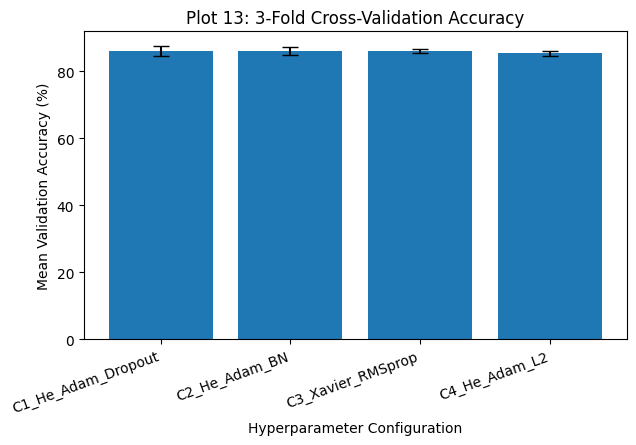

Best configuration by mean CV accuracy: C1_He_Adam_Dropout


In [32]:
# Plot 13 — 5(3)-Fold Cross-Validation Accuracy with error bars
names = list(configs_cv.keys())
means = [np.mean(cv_results[n])*100 for n in names]
sds   = [np.std(cv_results[n])*100 for n in names]

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(names, means, yerr=sds, capsize=6)
ax.set_ylabel('Mean Validation Accuracy (%)')
ax.set_xlabel('Hyperparameter Configuration')
ax.set_title(f'Plot 13: {CV_FOLDS}-Fold Cross-Validation Accuracy')
plt.xticks(rotation=20, ha='right')
save_plot(fig, 'Plot13_CV_Accuracy')

best_config_name = names[int(np.argmax(means))]
print("Best configuration by mean CV accuracy:", best_config_name)


## Task 9 — Final Model: Retrain, Test Evaluation, Confusion Matrix

In [33]:
# Retrain the best configuration on the FULL pooled train+val cached features
best_cfg = configs_cv[best_config_name]
tf.random.set_seed(SEED)
final_model = build_head(init=best_cfg['init'], dropout=best_cfg['dropout'],
                          use_bn=best_cfg['use_bn'], l2_reg=best_cfg['l2_reg'])
t0 = time.time()
final_hist, final_secs = train_head(final_model, optimizer=best_cfg['opt'], lr=best_cfg['lr'],
                                     epochs=CV_EPOCHS + 4, Xtr=X_pool, ytr=y_pool,
                                     Xva=X_test, yva=y_test)  # monitor only; test not used for selection
train_time = time.time() - t0
n_params = final_model.count_params()


In [ ]:
# Evaluate on the untouched test set — Section 12: Final Model Evaluation
y_pred_prob = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

test_acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

cv_mean_final = np.mean(cv_results[best_config_name]) * 100
cv_sd_final   = np.std(cv_results[best_config_name]) * 100

final_eval_table = pd.DataFrame([
    {'Metric': 'Mean CV Accuracy',    'Value': f"{cv_mean_final:.2f}%"},
    {'Metric': 'CV Standard Deviation', 'Value': f"{cv_sd_final:.2f}%"},
    {'Metric': 'Test Accuracy',       'Value': f"{test_acc*100:.2f}%"},
    {'Metric': 'Precision (macro)',   'Value': f"{precision:.3f}"},
    {'Metric': 'Recall (macro)',      'Value': f"{recall:.3f}"},
    {'Metric': 'F1-score (macro)',    'Value': f"{f1:.3f}"},
    {'Metric': 'Training Time',       'Value': f"{train_time:.1f}s"},
    {'Metric': 'Number of Parameters','Value': f"{n_params:,}"},
]).set_index('Metric')

print(f"Best configuration selected by CV: {best_config_name}")
final_eval_table


In [ ]:
# Plot 14 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(9,8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('Predicted label'); ax.set_ylabel('True label')
ax.set_title('Plot 14: Confusion Matrix (Test Set)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
save_plot(fig, 'Plot14_ConfusionMatrix')

# Best-classified classes (highest per-class recall, i.e. diagonal / row sum)
row_sums = cm.sum(axis=1)
per_class_recall = np.divide(np.diag(cm), row_sums, out=np.zeros(NUM_CLASSES), where=row_sums > 0)
best_classes_idx = np.argsort(-per_class_recall)[:5]
print("Best-classified breeds (highest recall on test set):")
for idx in best_classes_idx:
    name = CLASS_NAMES.get(idx, f"class_{idx}")
    print(f"  {name:25s} recall={per_class_recall[idx]*100:.1f}%  (n={row_sums[idx]})")

# Most confused class pairs (by breed name)
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
top_confused_idx = np.dstack(np.unravel_index(np.argsort(-cm_offdiag, axis=None)[:5], cm.shape))[0]
print("\nTop confused (true -> predicted) breed pairs:")
for t, p in top_confused_idx:
    t_name = CLASS_NAMES.get(int(t), f"class_{t}")
    p_name = CLASS_NAMES.get(int(p), f"class_{p}")
    print(f"  {t_name:20s} -> {p_name:20s}   count={cm[t,p]}")


In [ ]:
# Plot 15 (Optional) — A few misclassified images
mis_idx = np.where(y_pred != y_test)[0][:6]
fig, axes = plt.subplots(2, 3, figsize=(10,7))
for ax, idx in zip(axes.ravel(), mis_idx):
    img = test_images[idx].astype('uint8')
    ax.imshow(img)
    true_name = CLASS_NAMES.get(int(y_test[idx]), str(y_test[idx]))
    pred_name = CLASS_NAMES.get(int(y_pred[idx]), str(y_pred[idx]))
    ax.set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
    ax.axis('off')
for ax in axes.ravel()[len(mis_idx):]:
    ax.axis('off')
fig.suptitle('Plot 15: Representative Misclassified Images')
fig.tight_layout()
save_plot(fig, 'Plot15_Misclassified')


## Task 10 — Overall Results Summary Table

In [ ]:
# Section 13 — Overall Results Summary Table
# Configuration | CV/Val Accuracy (%) | SD (%) | Test Accuracy (%) | Training Time (s)
# Only the K-Fold CV stage and the Final Model have a true CV accuracy + SD + held-out test
# accuracy (the manual's test set is only touched at the very end, Section 12). For every
# earlier individual study (initialization / regularization / optimizer / hyperparameter
# tuning) we report the best VALIDATION accuracy from that study instead (labelled
# accordingly), since re-running full 5-fold CV for each of them would blow the CPU time
# budget — this is noted explicitly for the report.

best_lr    = max(lr_results, key=lr_results.get)
best_bs    = max(bs_results, key=bs_results.get)
best_do    = max(do_results, key=do_results.get)
best_hparam_acc  = max(lr_results[best_lr], bs_results[best_bs], do_results[best_do])
best_hparam_time = {lr_results[best_lr]: lr_times[best_lr],
                     bs_results[best_bs]: bs_times[best_bs],
                     do_results[best_do]: do_times[best_do]}[best_hparam_acc]

best_init_name = max(init_histories, key=lambda k: init_histories[k]['val_accuracy'][-1])
best_reg_name  = max(reg_histories,  key=lambda k: reg_histories[k]['val_accuracy'][-1])
best_opt_name  = max(opt_histories,  key=lambda k: max(opt_histories[k]['val_accuracy']))

overall_rows = [
    dict(Configuration="Baseline (He init, Adam, no reg.)",
         Accuracy=init_histories['he']['val_accuracy'][-1]*100, SD=None, Test_Accuracy=None,
         Training_Time=init_times['he']),
    dict(Configuration=f"Best Initialization ({best_init_name})",
         Accuracy=init_histories[best_init_name]['val_accuracy'][-1]*100, SD=None, Test_Accuracy=None,
         Training_Time=init_times[best_init_name]),
    dict(Configuration=f"Best Regularization ({best_reg_name})",
         Accuracy=reg_histories[best_reg_name]['val_accuracy'][-1]*100, SD=None, Test_Accuracy=None,
         Training_Time=reg_times[best_reg_name]),
    dict(Configuration=f"Best Optimizer ({best_opt_name})",
         Accuracy=max(opt_histories[best_opt_name]['val_accuracy'])*100, SD=None, Test_Accuracy=None,
         Training_Time=opt_times[best_opt_name]),
    dict(Configuration="Best Hyperparameters (tuning)",
         Accuracy=best_hparam_acc, SD=None, Test_Accuracy=None,
         Training_Time=best_hparam_time),
    dict(Configuration="Fine-Tuned Model (Task 7B)",
         Accuracy=hist_ft.history['val_accuracy'][-1]*100, SD=None, Test_Accuracy=None,
         Training_Time=None),
    dict(Configuration=f"Final Model — {best_config_name} (selected by {CV_FOLDS}-fold CV)",
         Accuracy=cv_mean_final, SD=cv_sd_final, Test_Accuracy=test_acc*100,
         Training_Time=train_time),
]

overall_results_table = pd.DataFrame(overall_rows)
overall_results_table['Accuracy']      = overall_results_table['Accuracy'].map(lambda v: f"{v:.2f}%")
overall_results_table['SD']            = overall_results_table['SD'].map(lambda v: f"{v:.2f}%" if v is not None else "—")
overall_results_table['Test_Accuracy'] = overall_results_table['Test_Accuracy'].map(lambda v: f"{v:.2f}%" if v is not None else "—")
overall_results_table['Training_Time'] = overall_results_table['Training_Time'].map(lambda v: f"{v:.1f}s" if v is not None else "—")
overall_results_table = overall_results_table.rename(columns={
    'Accuracy': 'CV / Val Accuracy (%)', 'SD': 'CV SD (%)',
    'Test_Accuracy': 'Test Accuracy (%)', 'Training_Time': 'Training Time'
}).set_index('Configuration')

overall_results_table


## Task 11 — Package all EPS plots (600 dpi) for download

In [38]:
zip_path = '/content/Experiment5_Plots_EPS.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in sorted(os.listdir(PLOT_DIR)):
        zf.write(os.path.join(PLOT_DIR, fname), arcname=fname)
print("Zipped all plots to:", zip_path)

from google.colab import files
files.download(zip_path)


Zipped all plots to: /content/Experiment5_Plots_EPS.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>